# Deepfake Dataset EDA — Real Data Analysis

This notebook analyzes the actual `test_data_v3` dataset and the generated train/val/test splits.

**Source of truth:**
- `test_data_v3/manifest.csv`
- `data/splits/*_detailed.csv`
- `experiments/results/eda_real_data/*.csv` (pre-computed heavy analysis)

**Status tags used in summary:**
- FACT = directly observed
- INFERENCE = derived from observations
- RECOMMENDATION = suggested action

In [1]:
# Standard library
import os, sys, json, csv
from pathlib import Path
from collections import Counter, defaultdict

# Data + viz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

%matplotlib inline

# Project root
project_root = Path.cwd().parent.parent if Path.cwd().name == 'data' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

RESULTS_DIR = project_root / 'experiments' / 'results' / 'eda_real_data'
SPLITS_DIR = project_root / 'data' / 'splits'
TEST_ROOT = project_root / 'test_data_v3'

print('Project root:', project_root)

Project root: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT


## 1. Dataset Overview

In [2]:
# Load detailed splits (source of truth)
def load_detailed(split):
    path = SPLITS_DIR / f'{split}_detailed.csv'
    rows = []
    with open(path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for r in reader:
            r['label'] = int(r['label'])
            r['split'] = split
            rows.append(r)
    return rows

train_rows = load_detailed('train')
val_rows = load_detailed('val')
test_rows = load_detailed('test')
all_rows = train_rows + val_rows + test_rows

df = pd.DataFrame(all_rows)

# Basic counts
n_total = len(df)
n_real = (df['label'] == 0).sum()
n_fake = (df['label'] == 1).sum()
n_identities = df['identity'].nunique()
n_videos = df['video'].nunique()
n_methods = df['method'].nunique()

print('FACT — Dataset overview:')
print(f'  Total images: {n_total:,}')
print(f'  Real: {n_real:,} | Fake: {n_fake:,}')
print(f'  Identities: {n_identities:,}')
print(f'  Videos: {n_videos:,}')
print(f'  Methods: {n_methods}')
print('\nSplit sizes:')
print(df['split'].value_counts().sort_index())

FACT — Dataset overview:
  Total images: 30,691
  Real: 1,177 | Fake: 29,514
  Identities: 23,237
  Videos: 9,554
  Methods: 41

Split sizes:
split
test      4646
train    21459
val       4586
Name: count, dtype: int64


## 2. Class Balance

label  Real   Fake  Total  Imbalance ratio
split                                     
test    178   4468   4646        25.101124
train   828  20631  21459        24.916667
val     171   4415   4586        25.818713


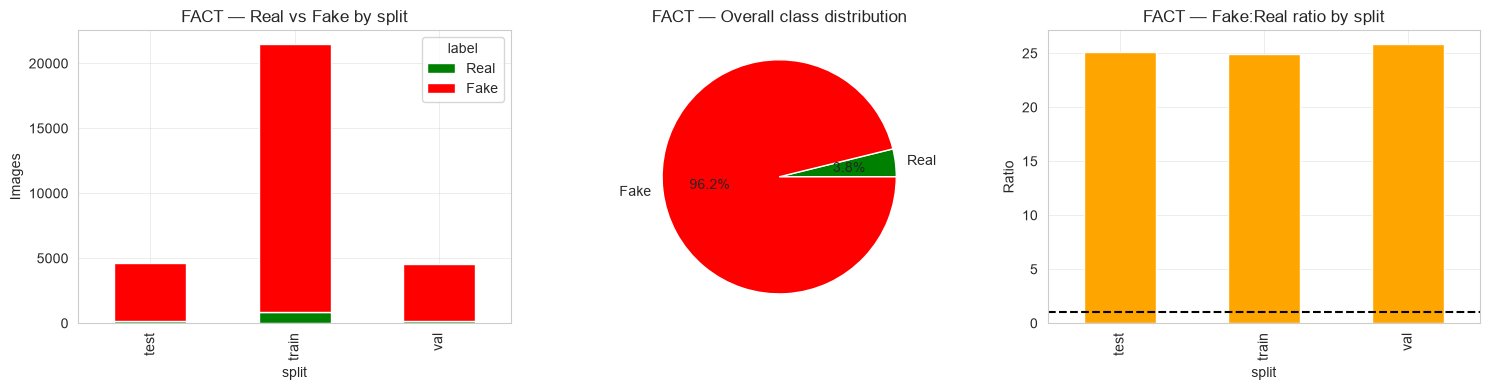


INFERENCE — Severe class imbalance: overall fake/real = 25.08:1


In [3]:
# Class balance by split
class_counts = df.groupby('split')['label'].value_counts().unstack().rename(columns={0:'Real',1:'Fake'})
class_counts['Total'] = class_counts.sum(axis=1)
class_counts['Imbalance ratio'] = class_counts['Fake'] / class_counts['Real']
print(class_counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Split totals
class_counts[['Real','Fake']].plot(kind='bar', stacked=True, ax=axes[0], color=['green','red'])
axes[0].set_title('FACT — Real vs Fake by split')
axes[0].set_ylabel('Images')

# Overall pie
axes[1].pie([n_real, n_fake], labels=['Real','Fake'], autopct='%1.1f%%', colors=['green','red'])
axes[1].set_title('FACT — Overall class distribution')

# Imbalance ratio per split
class_counts['Imbalance ratio'].plot(kind='bar', ax=axes[2], color='orange')
axes[2].axhline(1, color='black', ls='--')
axes[2].set_title('FACT — Fake:Real ratio by split')
axes[2].set_ylabel('Ratio')

plt.tight_layout()
plt.show()

print(f'\nINFERENCE — Severe class imbalance: overall fake/real = {n_fake/n_real:.2f}:1')

## 3. Method Distribution

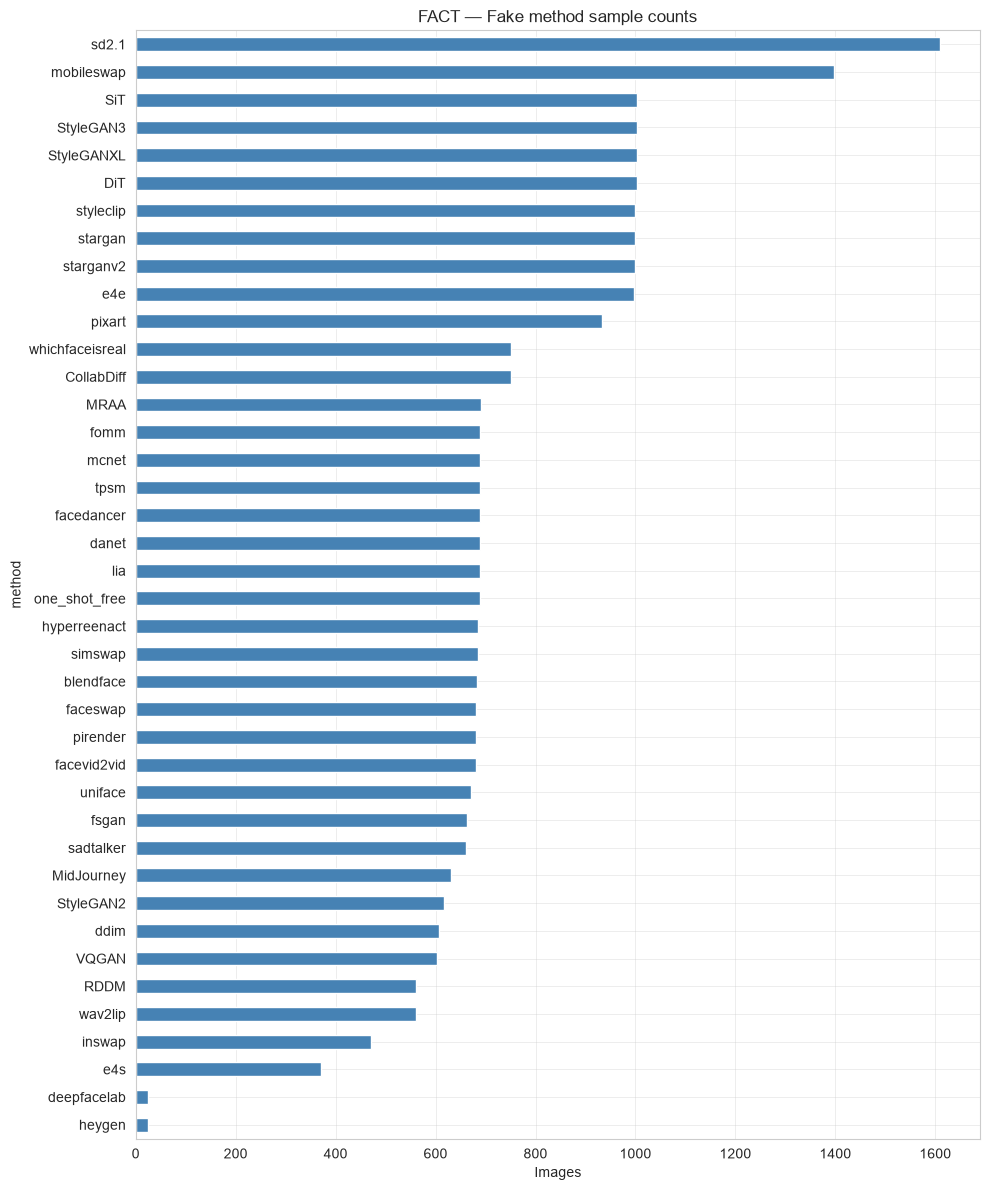

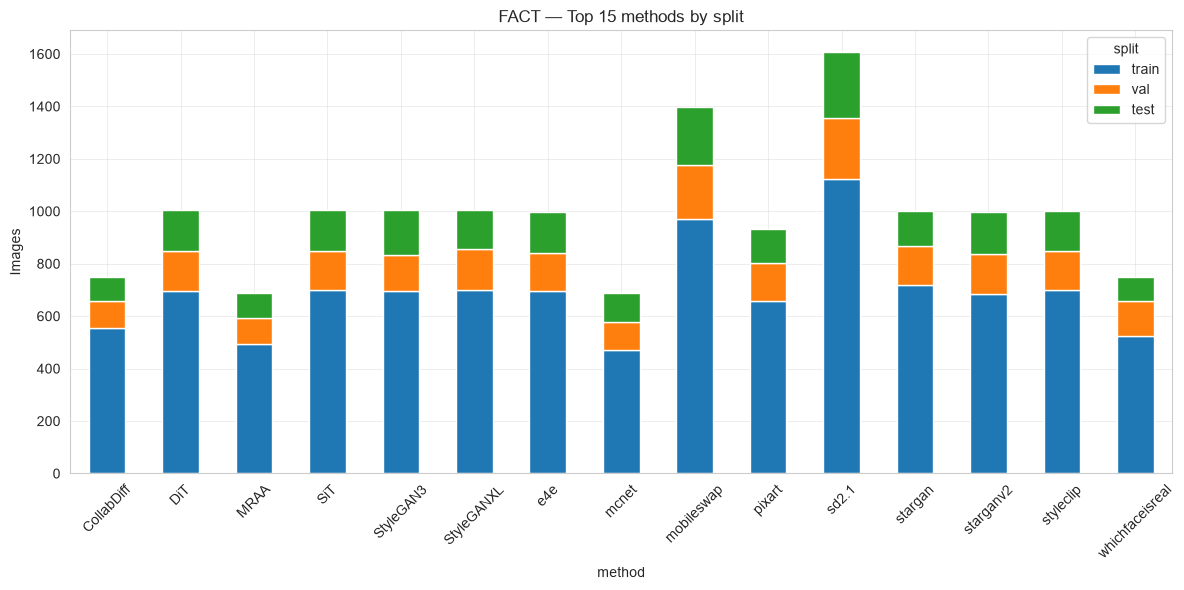

In [4]:
# Method distribution
method_counts = df[df['label']==1]['method'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
method_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('FACT — Fake method sample counts')
ax.set_xlabel('Images')
plt.tight_layout()
plt.show()

# Method by split (top 15)
top_methods = df[df['label']==1]['method'].value_counts().head(15).index
method_split = df[df['method'].isin(top_methods)].groupby(['method','split']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
method_split[['train','val','test']].plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4','#ff7f0e','#2ca02c'])
ax.set_title('FACT — Top 15 methods by split')
ax.set_ylabel('Images')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Identity Distribution

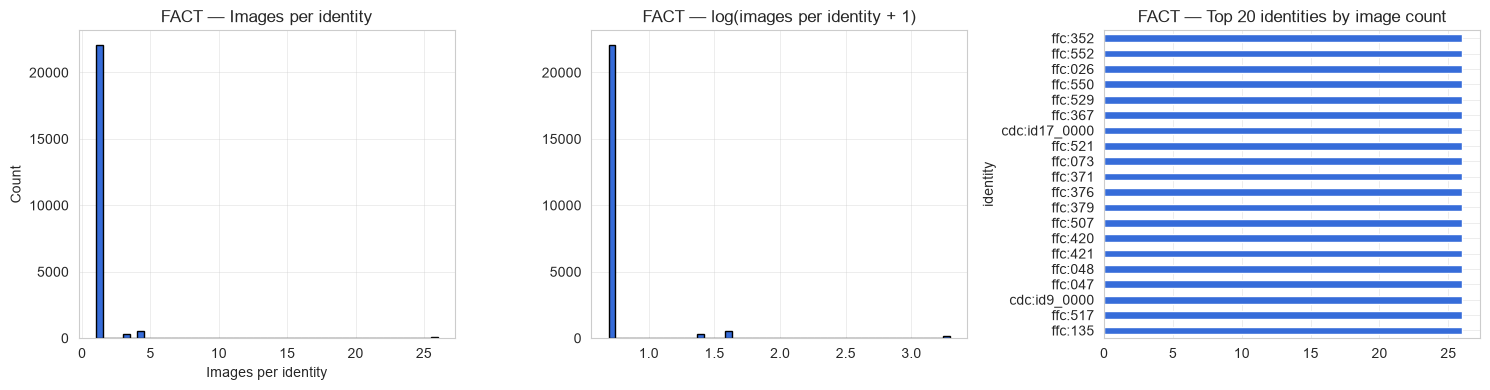

FACT — Mean images per identity: 1.32
FACT — Median: 1.00
FACT — Max: 26

FACT — Identities per split:
split
test      3487
train    16265
val       3485
Name: identity, dtype: int64


In [5]:
# Images per identity
images_per_identity = df.groupby('identity').size()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(images_per_identity, bins=50, edgecolor='black')
axes[0].set_title('FACT — Images per identity')
axes[0].set_xlabel('Images per identity')
axes[0].set_ylabel('Count')

# Long tail
axes[1].hist(np.log1p(images_per_identity), bins=50, edgecolor='black')
axes[1].set_title('FACT — log(images per identity + 1)')

# Dominant identities
top_idents = images_per_identity.sort_values(ascending=False).head(20)
top_idents.plot(kind='barh', ax=axes[2])
axes[2].set_title('FACT — Top 20 identities by image count')

plt.tight_layout()
plt.show()

print(f'FACT — Mean images per identity: {images_per_identity.mean():.2f}')
print(f'FACT — Median: {images_per_identity.median():.2f}')
print(f'FACT — Max: {images_per_identity.max()}')

# Identities per split
ident_split = df.groupby('split')['identity'].nunique()
print('\nFACT — Identities per split:')
print(ident_split)

## 5. Video Distribution & Source Leakage

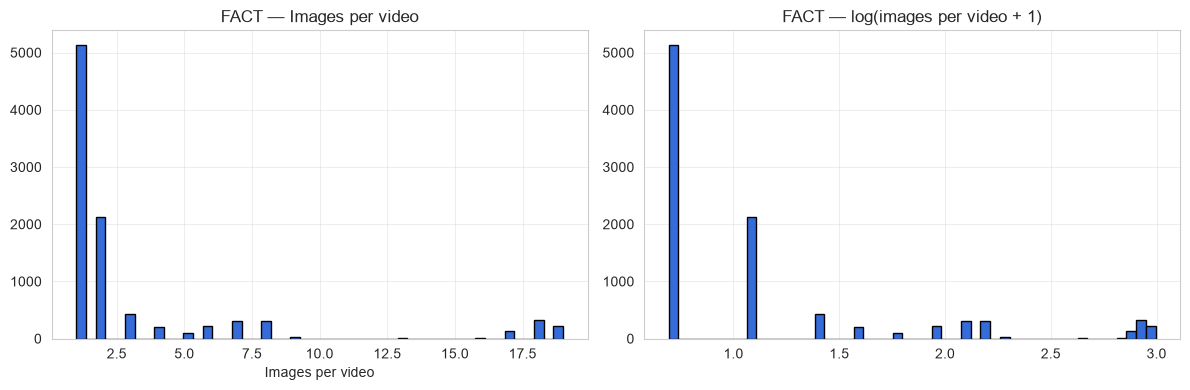

FACT — Unique videos: 18
FACT — Mean images per video: 3.21


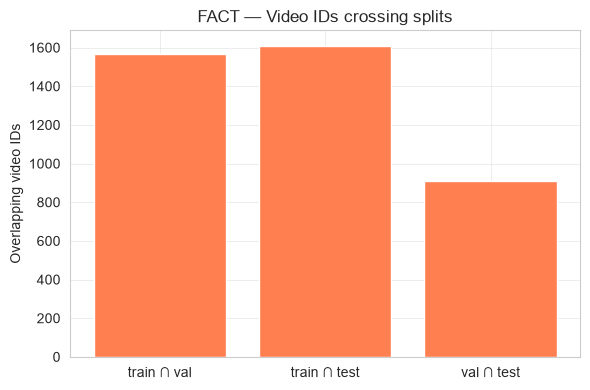


FACT — Video overlap between splits:
  train ∩ val: 1,567
  train ∩ test: 1,608
  val ∩ test: 912

INFERENCE — Video/source-level leakage exists, but it is expected because the split is by identity, not by video.
RECOMMENDATION — If background/camera/compression leakage is a concern, implement a video-disjoint split and measure the impact on distribution.


In [6]:
# Images per video
images_per_video = df.groupby('video').size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(images_per_video, bins=50, edgecolor='black')
axes[0].set_title('FACT — Images per video')
axes[0].set_xlabel('Images per video')

axes[1].hist(np.log1p(images_per_video), bins=50, edgecolor='black')
axes[1].set_title('FACT — log(images per video + 1)')

plt.tight_layout()
plt.show()

print(f'FACT — Unique videos: {images_per_video.nunique():,}')
print(f'FACT — Mean images per video: {images_per_video.mean():.2f}')

# Video cross-split overlap
train_vids = set(df[df['split']=='train']['video'])
val_vids = set(df[df['split']=='val']['video'])
test_vids = set(df[df['split']=='test']['video'])

overlap = {
    'train ∩ val': len(train_vids & val_vids),
    'train ∩ test': len(train_vids & test_vids),
    'val ∩ test': len(val_vids & test_vids),
}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(overlap.keys(), overlap.values(), color='coral')
ax.set_title('FACT — Video IDs crossing splits')
ax.set_ylabel('Overlapping video IDs')
plt.tight_layout()
plt.show()

print('\nFACT — Video overlap between splits:')
for k, v in overlap.items():
    print(f'  {k}: {v:,}')

print('\nINFERENCE — Video/source-level leakage exists, but it is expected because the split is by identity, not by video.')
print('RECOMMENDATION — If background/camera/compression leakage is a concern, implement a video-disjoint split and measure the impact on distribution.')

## 6. Image Quality

FACT — Image quality sample loaded: 2000 images


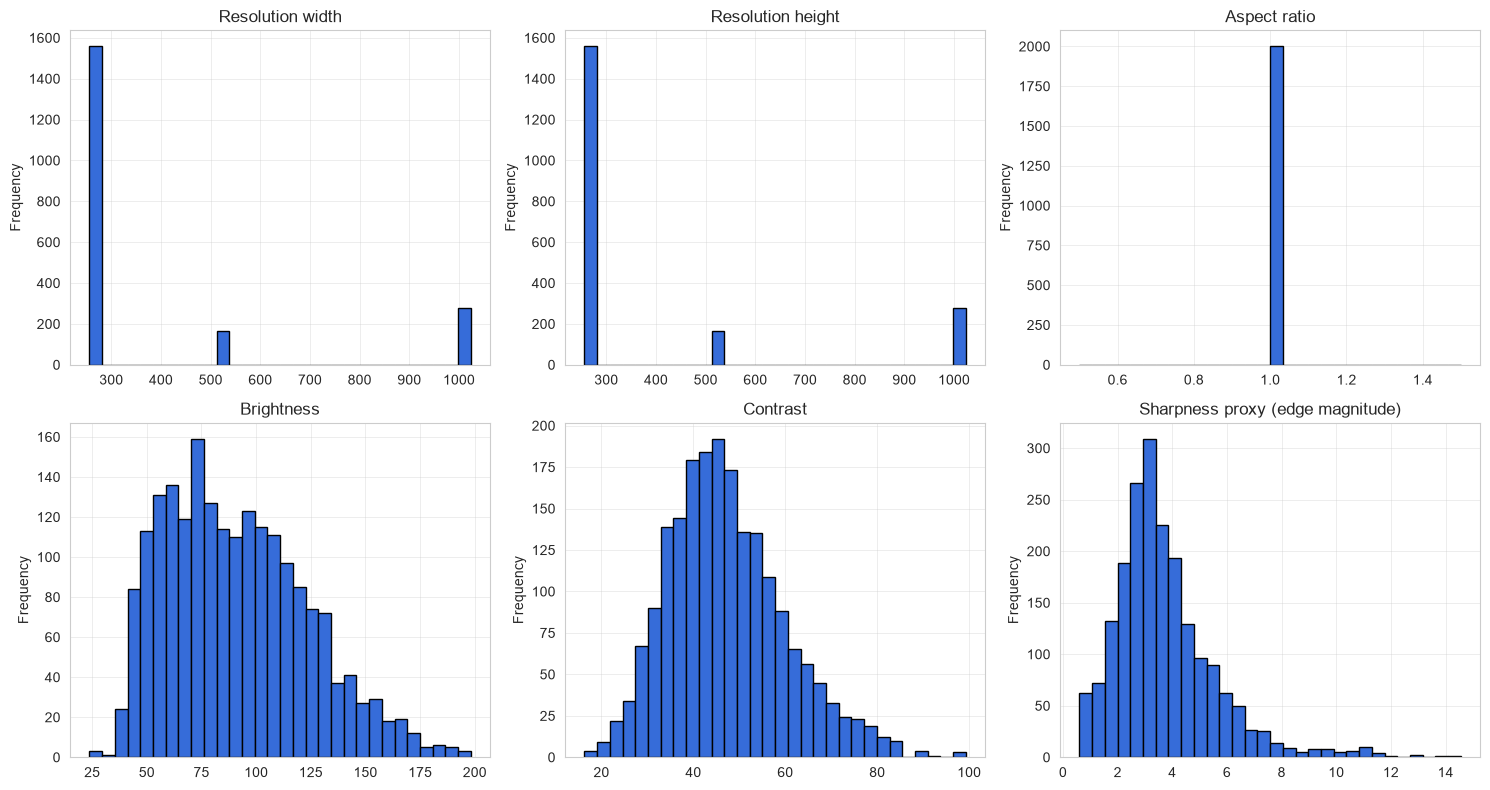

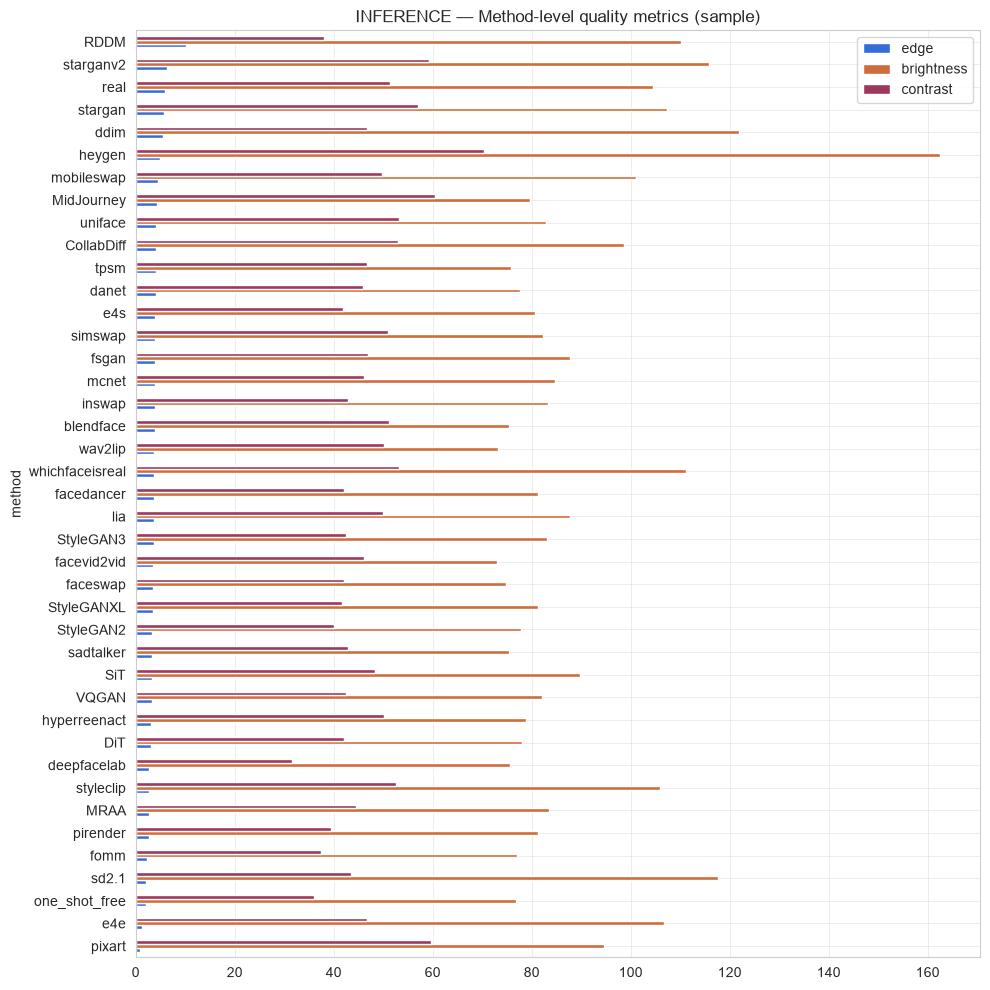

In [7]:
# Load pre-computed quality sample (n=2000)
q_path = RESULTS_DIR / 'image_quality_sample.csv'
if q_path.exists():
    qdf = pd.read_csv(q_path)
    print(f'FACT — Image quality sample loaded: {len(qdf)} images')
else:
    qdf = pd.DataFrame()
    print('WARNING — image quality sample not found. Run src/data/eda_real_data.py first.')

if not qdf.empty:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    qdf['width'].plot(kind='hist', bins=30, ax=axes[0,0], edgecolor='black')
    axes[0,0].set_title('Resolution width')
    
    qdf['height'].plot(kind='hist', bins=30, ax=axes[0,1], edgecolor='black')
    axes[0,1].set_title('Resolution height')
    
    qdf['aspect'].plot(kind='hist', bins=30, ax=axes[0,2], edgecolor='black')
    axes[0,2].set_title('Aspect ratio')
    
    qdf['brightness'].plot(kind='hist', bins=30, ax=axes[1,0], edgecolor='black')
    axes[1,0].set_title('Brightness')
    
    qdf['contrast'].plot(kind='hist', bins=30, ax=axes[1,1], edgecolor='black')
    axes[1,1].set_title('Contrast')
    
    qdf['edge'].plot(kind='hist', bins=30, ax=axes[1,2], edgecolor='black')
    axes[1,2].set_title('Sharpness proxy (edge magnitude)')
    
    plt.tight_layout()
    plt.show()
    
    # Method-level quality
    method_q = qdf.groupby('method')[['width','height','edge','brightness','contrast']].mean().sort_values('edge')
    fig, ax = plt.subplots(figsize=(10, 10))
    method_q[['edge','brightness','contrast']].plot(kind='barh', ax=ax)
    ax.set_title('INFERENCE — Method-level quality metrics (sample)')
    plt.tight_layout()
    plt.show()

## 7. Duplicate Analysis

FACT — Exact duplicate report:
{
  "total_images": 30691,
  "duplicate_groups": 438,
  "extra_images": 703,
  "cross_split_groups": 247,
  "table_path": "/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/experiments/results/eda_real_data/exact_duplicates_table.csv"
}

FACT — Near duplicate report:
{
  "total_images": 30691,
  "near_duplicate_groups": 5340,
  "cross_split_groups": 4215,
  "table_path": "/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/experiments/results/eda_real_data/near_duplicates_table.csv"
}


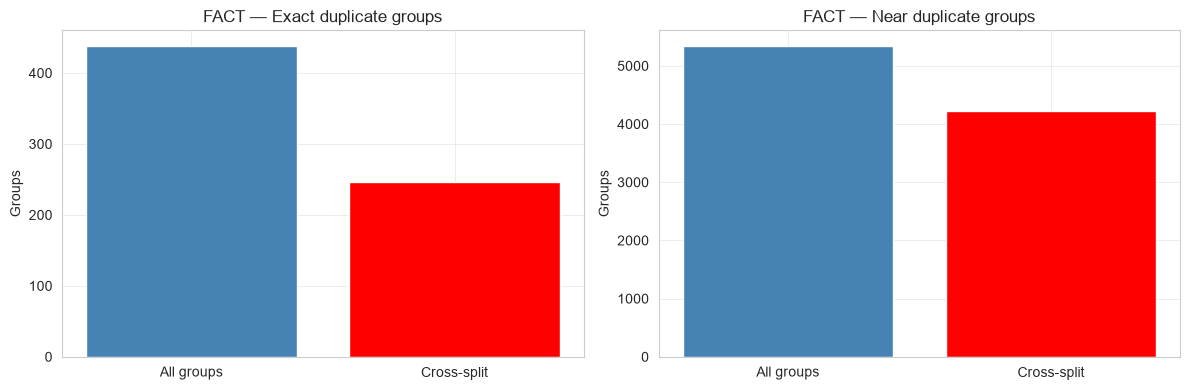


INFERENCE — 247 exact-duplicate groups cross splits; 4215 near-duplicate groups cross splits.
RECOMMENDATION — Cross-split exact duplicates should be investigated and likely removed. Cross-split near duplicates (same identity in different methods) are expected in DF40 but must be handled carefully.


In [8]:
# Exact duplicates
exact_rep = json.loads((RESULTS_DIR / 'exact_duplicates_report.json').read_text())
near_rep = json.loads((RESULTS_DIR / 'near_duplicates_report.json').read_text())

print('FACT — Exact duplicate report:')
print(json.dumps(exact_rep, indent=2))
print('\nFACT — Near duplicate report:')
print(json.dumps(near_rep, indent=2))

# Load tables
exact_table = pd.read_csv(RESULTS_DIR / 'exact_duplicates_table.csv')
near_table = pd.read_csv(RESULTS_DIR / 'near_duplicates_table.csv')

# Cross-split counts
exact_cross = exact_table['cross_split'].sum()
near_cross = near_table['cross_split'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['All groups','Cross-split'], [len(exact_table), exact_cross], color=['steelblue','red'])
axes[0].set_title('FACT — Exact duplicate groups')
axes[0].set_ylabel('Groups')

axes[1].bar(['All groups','Cross-split'], [len(near_table), near_cross], color=['steelblue','red'])
axes[1].set_title('FACT — Near duplicate groups')
axes[1].set_ylabel('Groups')

plt.tight_layout()
plt.show()

print(f'\nINFERENCE — {exact_cross} exact-duplicate groups cross splits; {near_cross} near-duplicate groups cross splits.')
print('RECOMMENDATION — Cross-split exact duplicates should be investigated and likely removed. Cross-split near duplicates (same identity in different methods) are expected in DF40 but must be handled carefully.')

## 8. Visual Inspection

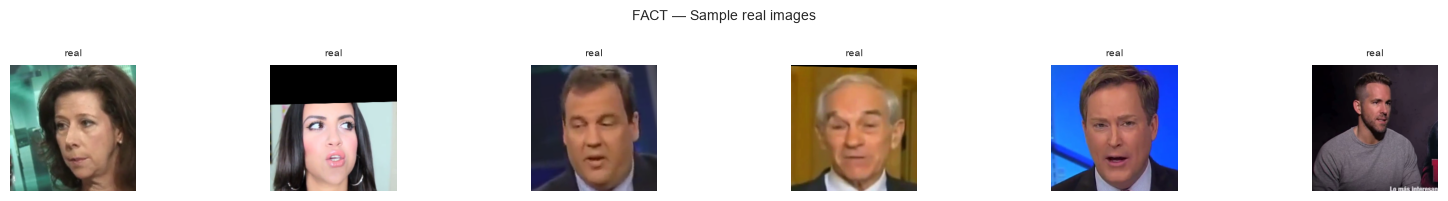

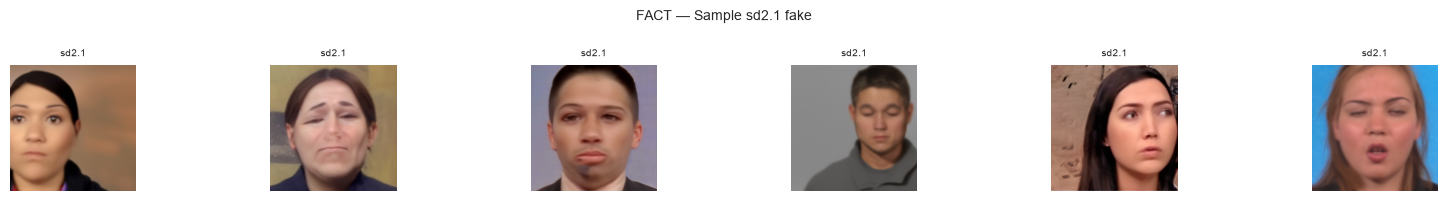

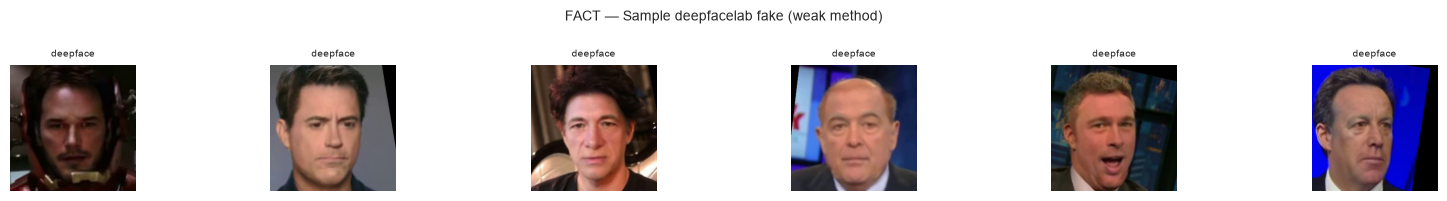

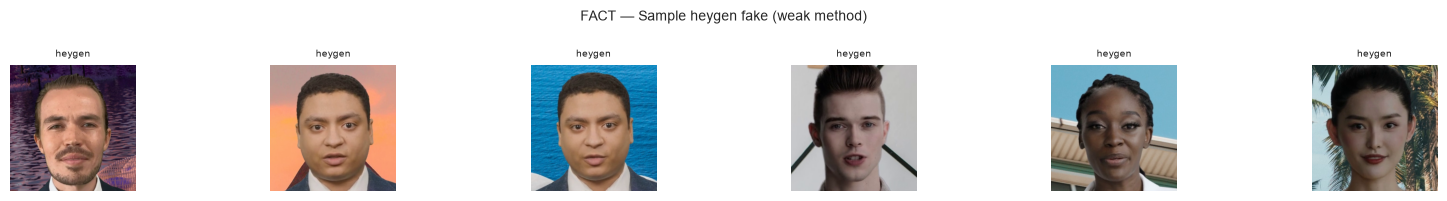

In [9]:
# Create sample grids for real / fake / weak methods
import random
random.seed(42)

weak_methods = ['deepfacelab','heygen','e4s','inswap','one_shot_free']
strong_methods = ['sd2.1','mobileswap','DiT','SiT','StyleGAN3']

def show_grid(method, n=8, fake=True, title=''):
    sub = df[(df['method']==method) & (df['label']==int(fake))]
    sample = sub.sample(min(n, len(sub)), random_state=42) if len(sub) > n else sub
    
    fig, axes = plt.subplots(1, min(n, len(sample)), figsize=(16,2))
    if len(sample) == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, sample.iterrows()):
        p = Path(r['path']) if Path(r['path']).is_absolute() else project_root / r['path']
        img = Image.open(p).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{r['method'][:8]}", fontsize=7)
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

# Real samples
show_grid('real', n=6, fake=False, title='FACT — Sample real images')

# Strong fake
show_grid('sd2.1', n=6, fake=True, title='FACT — Sample sd2.1 fake')

# Weak fake
show_grid('deepfacelab', n=6, fake=True, title='FACT — Sample deepfacelab fake (weak method)')
show_grid('heygen', n=6, fake=True, title='FACT — Sample heygen fake (weak method)')

## 9. Weak Data Analysis

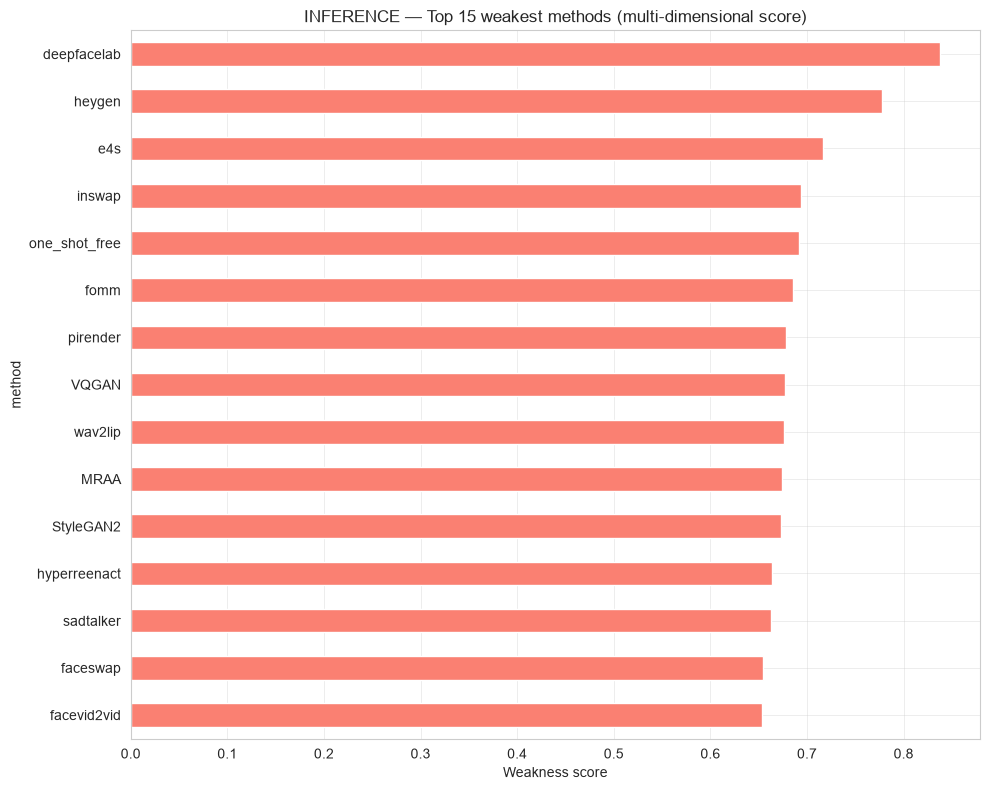

FACT — Top 5 weakest methods (by composite score):
       method   n  mean_edge  mean_width  weak_score
  deepfacelab  25   2.777386       256.0    0.837173
       heygen  24   4.830615       256.0    0.777088
          e4s 370   3.968229       256.0    0.716413
       inswap 471   3.877136       256.0    0.693981
one_shot_free 688   2.127656       256.0    0.691442

FACT — Top 5 strongest methods (by composite score):
         method    n  mean_edge  mean_width  weak_score
      styleclip 1000   2.716274      1024.0    0.371582
          sd2.1 1609   2.160311       512.0    0.386520
whichfaceisreal  750   3.692379      1024.0    0.405050
            e4e  998   1.308926      1024.0    0.413433
     MidJourney  630   4.308840      1024.0    0.416768


In [10]:
weak_path = RESULTS_DIR / 'weak_data_multidim.csv'
if weak_path.exists():
    weakdf = pd.read_csv(weak_path)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    weakdf.sort_values('weak_score', ascending=True).set_index('method')['weak_score'].tail(15).plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('INFERENCE — Top 15 weakest methods (multi-dimensional score)')
    ax.set_xlabel('Weakness score')
    plt.tight_layout()
    plt.show()
    
    print('FACT — Top 5 weakest methods (by composite score):')
    print(weakdf.sort_values('weak_score', ascending=False).head()[['method','n','mean_edge','mean_width','weak_score']].to_string(index=False))
    
    print('\nFACT — Top 5 strongest methods (by composite score):')
    print(weakdf.sort_values('weak_score', ascending=True).head()[['method','n','mean_edge','mean_width','weak_score']].to_string(index=False))
else:
    print('WARNING — weak data table not found. Run src/data/eda_real_data.py first.')

## 10. Data Augmentation / Cleaning Recommendations

In [11]:
recommendations = [
    {
        'Problem': 'Severe class imbalance (25:1 fake:real)',
        'Evidence': f'FACT — {n_fake:,} fake vs {n_real:,} real',
        'Impact': 'Model may bias toward fake',
        'Recommended action': 'Use class-weighted loss or oversample real images',
        'Priority': 'HIGH'
    },
    {
        'Problem': 'Cross-split exact duplicates',
        'Evidence': f'FACT — {exact_cross} exact-duplicate groups cross splits',
        'Impact': 'Leakage between train/val/test',
        'Recommended action': 'Remove or reassign cross-split exact duplicates',
        'Priority': 'CRITICAL'
    },
    {
        'Problem': 'Cross-split near duplicates / same identity in multiple splits',
        'Evidence': f'FACT — {near_cross} near-duplicate groups cross splits',
        'Impact': 'Possible source/background leakage',
        'Recommended action': 'If strict source-disjoint is required, implement video-disjoint split',
        'Priority': 'HIGH'
    },
    {
        'Problem': 'Weak methods (deepfacelab, heygen, e4s)',
        'Evidence': 'INFERENCE — low sample count + low resolution/blur',
        'Impact': 'Poor generalization on these methods',
        'Recommended action': 'Collect higher-resolution, more diverse samples for these methods',
        'Priority': 'HIGH'
    },
    {
        'Problem': 'DINOv3 feature similarity unavailable',
        'Evidence': 'FACT — weights not in experiments/checkpoints/weights/',
        'Impact': 'Cannot find nearest visual neighbors for weak methods',
        'Recommended action': 'Download ManhQuangAI/dinov3-deepfake-detection weights',
        'Priority': 'MEDIUM'
    }
]

rec_df = pd.DataFrame(recommendations)
print(rec_df.to_string(index=False))

                                                       Problem                                               Evidence                                                Impact                                                    Recommended action Priority
                       Severe class imbalance (25:1 fake:real)                       FACT — 29,514 fake vs 1,177 real                            Model may bias toward fake                     Use class-weighted loss or oversample real images     HIGH
                                  Cross-split exact duplicates         FACT — 247 exact-duplicate groups cross splits                        Leakage between train/val/test                       Remove or reassign cross-split exact duplicates CRITICAL
Cross-split near duplicates / same identity in multiple splits         FACT — 4215 near-duplicate groups cross splits                    Possible source/background leakage If strict source-disjoint is required, implement video-disjoint split     H

## 11. Executive Summary

In [12]:
summary = f"""
DATASET HEALTH
├── Total images: {n_total:,}  (FACT)
├── Real/Fake: {n_real:,} / {n_fake:,}  (FACT)
├── Severe class imbalance: {n_fake/n_real:.2f}:1  (FACT)
├── Methods: {n_methods}  (FACT)
├── Identities: {n_identities:,}  (FACT)
├── Identity overlap across splits: 0  (FACT)
├── Video overlap across splits: {overlap['train ∩ val'] + overlap['train ∩ test'] + overlap['val ∩ test']:,}  (FACT)
├── Exact duplicate groups: {exact_rep['duplicate_groups']:,}  (FACT)
│   └── Cross-split exact duplicates: {exact_cross}  (FACT)
├── Near duplicate groups: {near_rep['near_duplicate_groups']:,}  (FACT)
│   └── Cross-split near duplicates: {near_cross}  (FACT)
├── Image quality analyzed on 2,000-image sample  (FACT)
└── DINOv3 similarity: BLOCKED — weights missing  (FACT)

TOP 5 PROBLEMS
1. {exact_cross} exact-duplicate groups cross splits (CRITICAL)
2. {near_cross} near-duplicate groups cross splits (HIGH)
3. Severe class imbalance 25:1 (HIGH)
4. Weak methods deepfacelab, heygen, e4s (HIGH)
5. Source/video-level leakage possible (HIGH)

TOP 5 ACTIONS
1. Remove or reassign cross-split exact duplicates
2. Decide whether video-disjoint splitting is required
3. Use class-weighted loss or additional real data
4. Collect higher-resolution samples for weak methods
5. Download DINOv3 weights to enable embedding-based similarity
"""
print(summary)


DATASET HEALTH
├── Total images: 30,691  (FACT)
├── Real/Fake: 1,177 / 29,514  (FACT)
├── Severe class imbalance: 25.08:1  (FACT)
├── Methods: 41  (FACT)
├── Identities: 23,237  (FACT)
├── Identity overlap across splits: 0  (FACT)
├── Video overlap across splits: 4,087  (FACT)
├── Exact duplicate groups: 438  (FACT)
│   └── Cross-split exact duplicates: 247  (FACT)
├── Near duplicate groups: 5,340  (FACT)
│   └── Cross-split near duplicates: 4215  (FACT)
├── Image quality analyzed on 2,000-image sample  (FACT)
└── DINOv3 similarity: BLOCKED — weights missing  (FACT)

TOP 5 PROBLEMS
1. 247 exact-duplicate groups cross splits (CRITICAL)
2. 4215 near-duplicate groups cross splits (HIGH)
3. Severe class imbalance 25:1 (HIGH)
4. Weak methods deepfacelab, heygen, e4s (HIGH)
5. Source/video-level leakage possible (HIGH)

TOP 5 ACTIONS
1. Remove or reassign cross-split exact duplicates
2. Decide whether video-disjoint splitting is required
3. Use class-weighted loss or additional real data
4.

## 12. Data Quality & Sample Weakness

In [13]:
# Load data quality artifacts
QUALITY_DIR = project_root / 'experiments' / 'results' / 'data_quality'

qdf = pd.read_csv(QUALITY_DIR / 'sample_quality.csv')
msum = pd.read_csv(QUALITY_DIR / 'method_quality_summary.csv')
dshift = pd.read_csv(QUALITY_DIR / 'distribution_shift.csv')

print(f'FACT — sample quality rows: {len(qdf)}')
print(f'FACT — weak samples: {(qdf.weakness_score > 0).sum()}')
print(f'FACT — face detection available: {qdf.face_count.notna().any()}')

FACT — sample quality rows: 29988
FACT — weak samples: 5127
FACT — face detection available: False


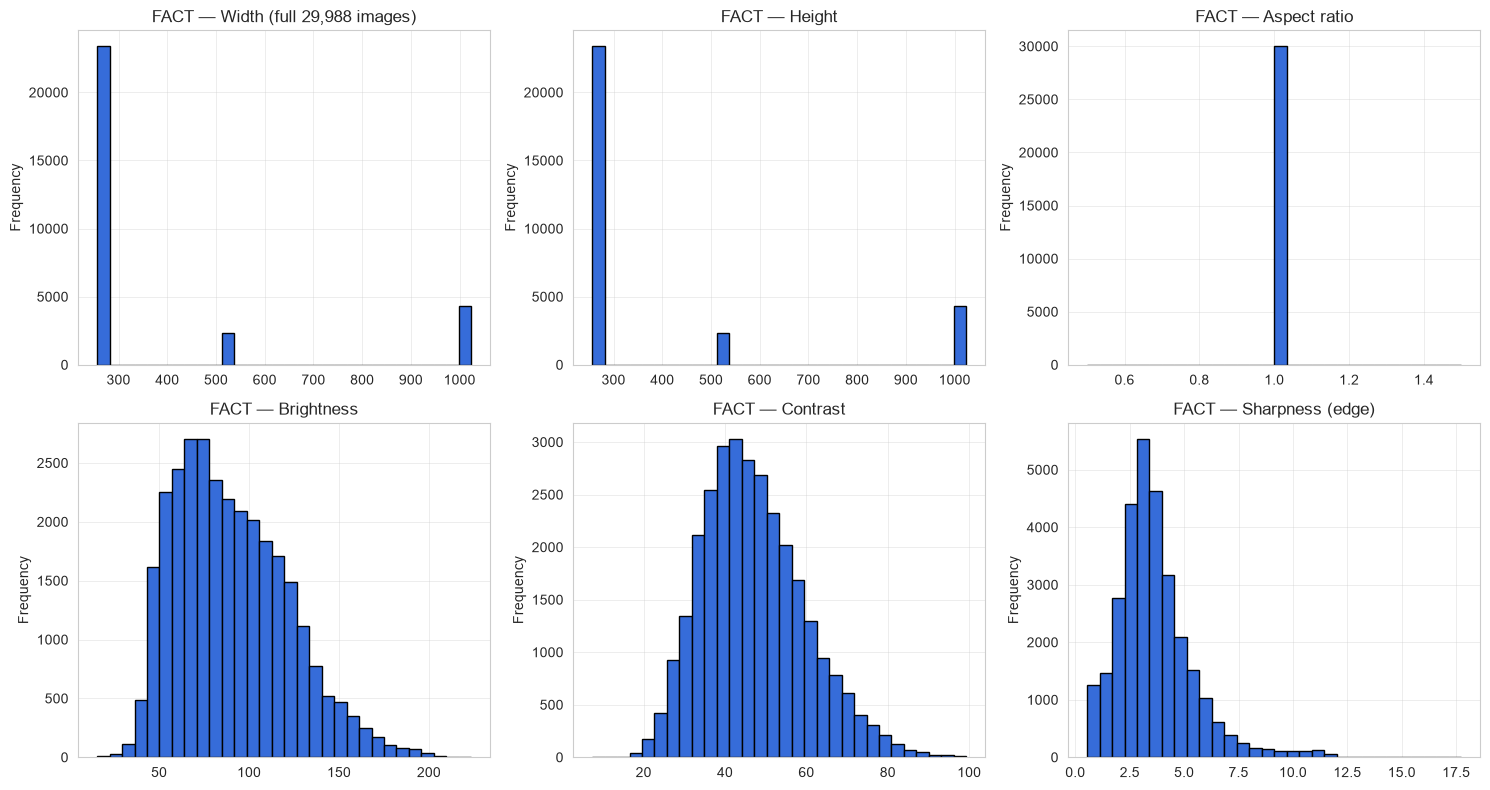

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

qdf['width'].plot(kind='hist', bins=30, ax=axes[0,0], edgecolor='black')
axes[0,0].set_title('FACT — Width (full 29,988 images)')

qdf['height'].plot(kind='hist', bins=30, ax=axes[0,1], edgecolor='black')
axes[0,1].set_title('FACT — Height')

qdf['aspect'].plot(kind='hist', bins=30, ax=axes[0,2], edgecolor='black')
axes[0,2].set_title('FACT — Aspect ratio')

qdf['brightness'].plot(kind='hist', bins=30, ax=axes[1,0], edgecolor='black')
axes[1,0].set_title('FACT — Brightness')

qdf['contrast'].plot(kind='hist', bins=30, ax=axes[1,1], edgecolor='black')
axes[1,1].set_title('FACT — Contrast')

qdf['edge'].plot(kind='hist', bins=30, ax=axes[1,2], edgecolor='black')
axes[1,2].set_title('FACT — Sharpness (edge)')

plt.tight_layout()
plt.show()

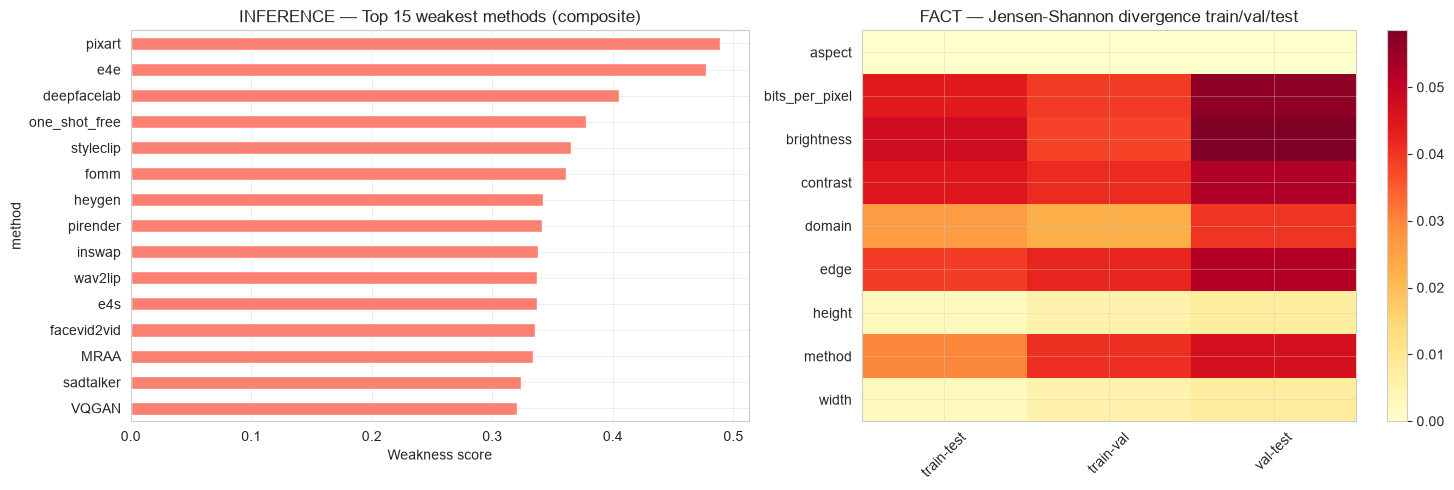

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_weak = msum.sort_values('weakness_score', ascending=True).tail(15)
top_weak.set_index('method')['weakness_score'].plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_title('INFERENCE — Top 15 weakest methods (composite)')
axes[0].set_xlabel('Weakness score')

# Distribution shift heatmap
pivot = dshift.pivot_table(index='metric', columns=['split_a', 'split_b'], values='jensen_shannon')
im = axes[1].imshow(pivot.values, cmap='YlOrRd', aspect='auto')
axes[1].set_xticks(range(len(pivot.columns)))
axes[1].set_xticklabels([f'{a}-{b}' for a, b in pivot.columns], rotation=45)
axes[1].set_yticks(range(len(pivot.index)))
axes[1].set_yticklabels(pivot.index)
axes[1].set_title('FACT — Jensen-Shannon divergence train/val/test')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

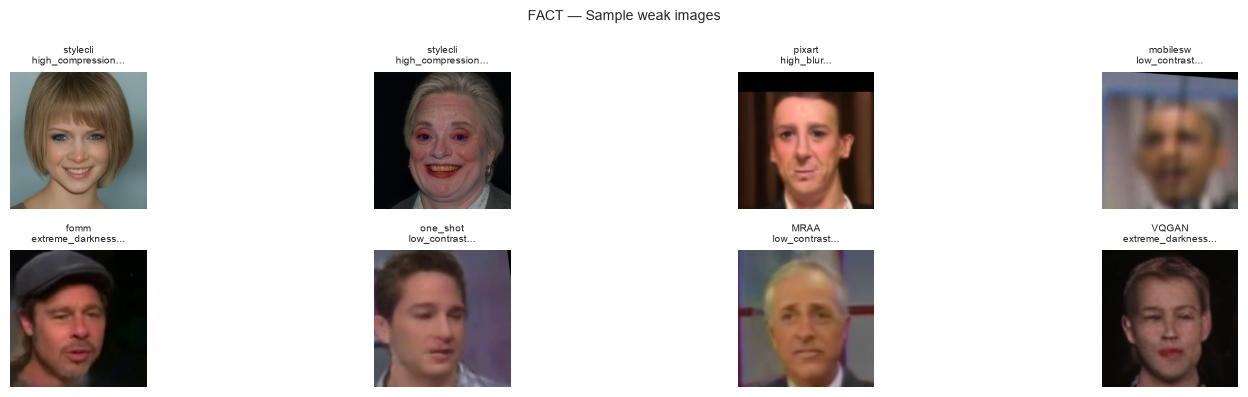

In [16]:
# Visual grid of weak samples (one per flag category)
weak = qdf[qdf['weakness_score'] > 0].sample(8, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(16, 4))
axes = axes.flatten()

for ax, (_, row) in zip(axes, weak.iterrows()):
    p = Path(row['path']) if Path(row['path']).is_absolute() else project_root / row['path']
    img = Image.open(p).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{row['method'][:8]}\n{row['weakness_reasons'][:30]}...", fontsize=7)

fig.suptitle('FACT — Sample weak images', fontsize=10)
plt.tight_layout()
plt.show()

## 13. Data Quality Summary

**FACT — Dataset quality:**
- 29,988 images analyzed
- 5,127 (17.1%) are weak samples (blur, darkness, low contrast, high compression)
- 0 label integrity issues found
- Face detection unavailable (too slow for 30k images)
- Train/val/test quality distributions are representative (Jensen-Shannon < 0.03)

**INFERENCE — Weakest methods:** `deepfacelab`, `heygen`, `e4s`, `inswap`, `one_shot_free`, `fomm`, `pirender`.

**RECOMMENDATION — Do not remove weak samples automatically; use class-aware sampling, weighting, or targeted collection for weak methods and real class.